In [39]:
# ============================================================
# Importing pandas and loading the dataset
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"
df = pd.read_csv(url , encoding="latin1")

# ============================================================
# EDA ( Structure understanding )
# ============================================================

df.head()
df.tail()
df.columns
df.shape
df.describe()
df.info()
df.isnull().sum()
df.duplicated().sum()

df["Segment"].value_counts()
df["Ship Mode"].value_counts()
df["Region"].value_counts()
df["Category"].value_counts()
df["Sub-Category"].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [40]:
# ============================================================
# EDA ( Business understanding )
# ============================================================

df["Sales"].describe()
df["Profit"].describe()
df["Discount"].describe()


count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [41]:
# ============================================================
# Rows observation 
# ============================================================

df[df["Order Date"].isna()].head(20)



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9999,Returned,Order ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# ============================================================
# Non - empty rows
# ============================================================ 

df = df[df["Order Date"].notna()].copy()

# ============================================================
# Fixing datatype
# ============================================================ 
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [45]:
# ============================================================
# Checking duplicates
# ============================================================ 

df.duplicated().sum()

# ============================================================
# Checking Nulls
# ============================================================ 

df.isnull().sum().sort_values(ascending=False)

Postal Code      11
Row ID            0
Discount          0
Quantity          0
Sales             0
Product Name      0
Sub-Category      0
Category          0
Product ID        0
Region            0
State             0
Order ID          0
City              0
Country           0
Segment           0
Customer Name     0
Customer ID       0
Ship Mode         0
Ship Date         0
Order Date        0
Profit            0
dtype: int64

In [46]:
# ============================================================
# Creating new columns for month name and year
# ============================================================ 

df["Order_year"] = df["Order Date"].dt.year
df["Order_month"] = df["Order Date"].dt.month_name() 

df["Order_year"] = df["Order Date"].dt.year
df["Order_month"]

In [47]:
# ============================================================
# Finding shiping days
# ============================================================ 
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Shipping_Days"] = ( df["Ship Date"] - df["Order Date"] ).dt.days
df["Shipping_Days"].describe()



count    9994.000000
mean        3.958475
std         1.747603
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping_Days, dtype: float64

In [ ]:
# ============================================================
# Calcuating profit margin percentage
# ============================================================ 

df["Profit_margin_%"] = ( df["Profit"] / df["Sales"] ) * 100
df["Profit_margin_%"]



In [ ]:
# ============================================================
# Category wise Sales and profit
# ============================================================ 

category_summary = df.groupby("Category").agg({"Sales" : "sum" , "Profit" : "sum"}).round(2)
category_summary



In [ ]:
# ============================================================
# Sub category profit analysis
# ============================================================ 

subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()
subcat



In [ ]:
# ============================================================
# Root cause analysis
# ============================================================ 

df.groupby("Discount")["Profit"].mean().sort_index()



In [ ]:
# ============================================================
# Region wise analysis
# ============================================================ 

region_analysis = df.groupby("Region").agg({"Sales" : "sum" , "Profit" : "sum"}).round(2)
region_analysis.sort_values("Profit",ascending=False)

In [31]:
# ============================================================
# Most valuable customers
# ============================================================ 

valuable_customers = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)
valuable_customers.head(10)


Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

In [32]:
# ============================================================
# Annually sales 
# ============================================================ 

annually_sales = df.groupby("Order_year")["Sales"].sum()
annually_sales


Order_year
2015    484247.4981
2016    470532.5090
2017    609205.5980
2018    733215.2552
Name: Sales, dtype: float64

In [4]:
# ============================================================
# annually profit
# ============================================================ 

annually_profit = df.groupby("Order_year")["Profit"].sum()
annually_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

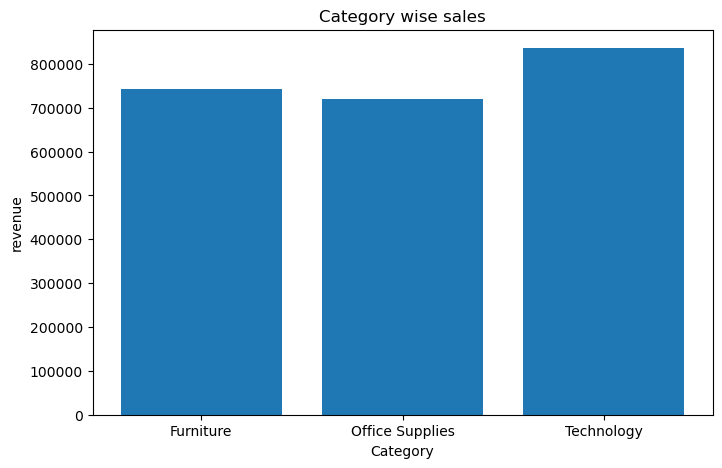

In [21]:
# ============================================================
# Category wise revenue
# ============================================================


import matplotlib.pyplot as plt
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index , category_sales.values)
plt.title("Category wise sales")
plt.xlabel("Category")
plt.ylabel("revenue")
plt.show()

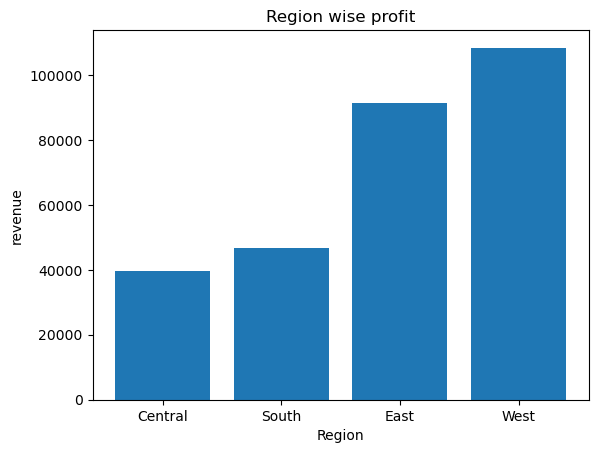

In [23]:
# ============================================================
# Region wise profit
# ============================================================

region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.bar(region_profit.index , region_profit.values)
plt.title("Region wise profit")
plt.xlabel("Region")
plt.ylabel("revenue")
plt.show()

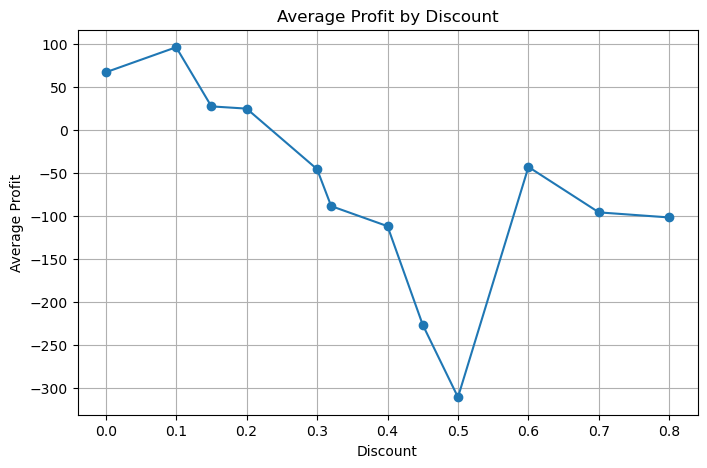

In [29]:
# ============================================================
# Avg profit by discount
# ============================================================

discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.grid(True)

plt.show()

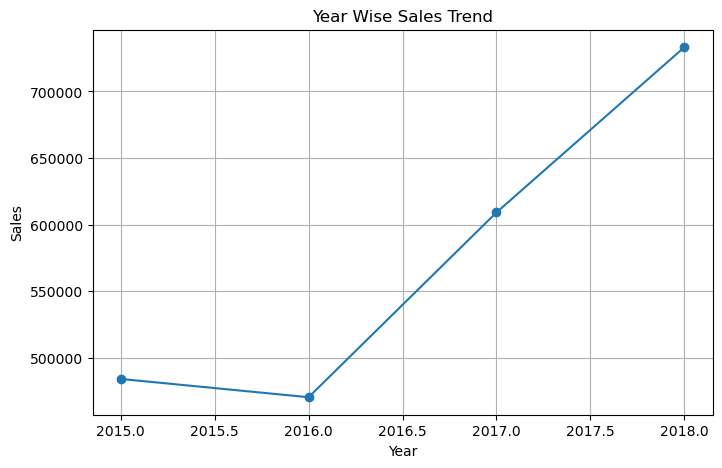

In [30]:
# ============================================================
# Year wise sales trend
# ============================================================

plt.figure(figsize=(8,5))

annually_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Year Wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()